# 📊 Reporte de Planificación Turística en Paraguay

Este notebook integra todos los análisis realizados:
- Exploración de datos
- Visualizaciones iniciales
- Mapas turísticos
- Proyecciones de visitantes
- Segmentación de turistas

Al final, se podrá exportar el reporte completo en **HTML o PDF**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Cargar dataset
df = pd.read_csv('../data/turistas.csv')
df.head()

,anio,ciudad,tipo_turismo,visitantes,gasto_promedio
0,2020,Asunción,Cultural,38181,429
1,2020,Asunción,Compras,38670,453
2,2020,Asunción,Receptivo,18104,249
3,2020,Encarnación,Cultural,30230,417
4,2020,Encarnación,Compras,16472,385


## 🔍 Exploración de Datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   anio            54 non-null     int64 
 1   ciudad          54 non-null     object
 2   tipo_turismo    54 non-null     object
 3   visitantes      54 non-null     int64 
 4   gasto_promedio  54 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.2+ KB
None
              anio    visitantes  gasto_promedio
count    54.000000     54.000000       54.000000
mean   2022.500000  27901.259259      338.277778
std       1.723861   7747.925444       93.419811
min    2020.000000  12025.000000      202.000000
25%    2021.000000  23050.750000      246.000000
50%    2022.500000  30239.500000      338.000000
75%    2024.000000  33436.000000      435.000000
max    2025.000000  38670.000000      482.000000


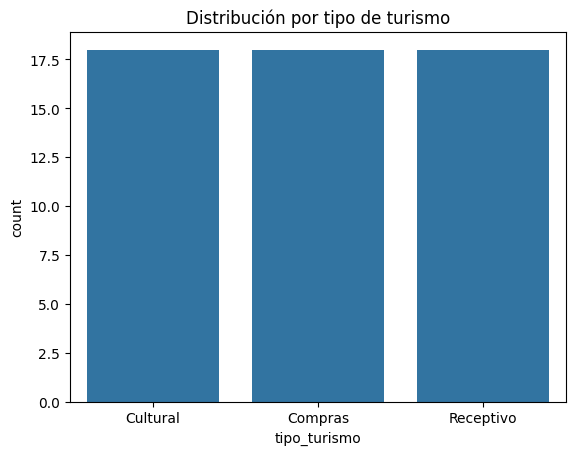

In [2]:
print(df.info())
print(df.describe())

sns.countplot(x='tipo_turismo', data=df)
plt.title('Distribución por tipo de turismo')
plt.show()

## 🗺️ Mapas Turísticos Interactivos

In [4]:
from pathlib import Path

coords = {
    'Asunción': [-25.2637, -57.5759],
    'Encarnación': [-27.3306, -55.8667],
    'Ciudad del Este': [-25.5167, -54.6167]
}

m = folium.Map(location=[-25.5, -57.0], zoom_start=6)
for idx, row in df.iterrows():
    if row['ciudad'] in coords:
        folium.CircleMarker(
            location=coords[row['ciudad']],
            radius=10 + row['visitantes']/5000,
            popup=f"{row['ciudad']} - {row['tipo_turismo']} ({row['visitantes']} visitantes)",
            color='blue', fill=True, fill_opacity=0.6
        ).add_to(m)

Path('../outputs').mkdir(parents=True, exist_ok=True)
m.save('../outputs/reporte_mapa_turismo.html')
m


## 📈 Proyecciones de Visitantes

In [ ]:
# Preparar datos
df_agg = df.groupby('anio')['visitantes'].sum().reset_index()
df_agg = df_agg.rename(columns={'anio': 'ds', 'visitantes': 'y'})
df_agg['ds'] = pd.to_datetime(df_agg['ds'], format='%Y')

# Prophet
prophet_model = Prophet()
prophet_model.fit(df_agg)
future = prophet_model.make_future_dataframe(periods=5, freq='Y')
forecast = prophet_model.predict(future)
prophet_model.plot(forecast)
plt.title('Proyección con Prophet (5 años)')
plt.show()

## 🧩 Segmentación de Turistas

In [ ]:
X = df[['visitantes','gasto_promedio']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df['segmento'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x='visitantes', y='gasto_promedio', hue='segmento', data=df, palette='Set2')
plt.title('Segmentación de turistas (KMeans)')
plt.show()
df[['ciudad','tipo_turismo','visitantes','gasto_promedio','segmento']]

## 📤 Exportar Reporte

In [ ]:
# Exportar reporte a HTML y PDF
!jupyter nbconvert --to html --output ../outputs/reporte_turismo.html reporte_turismo.ipynb
# Para PDF (requiere LaTeX instalado)
# !jupyter nbconvert --to pdf --output ../outputs/reporte_turismo.pdf reporte_turismo.ipynb